# NAVYA — Hyperparameter Optimisation

This notebook is a panel-facing audit of the single authoritative tuning process in Notebook 05. It displays the grouped-CV selection result without launching another hyperparameter search or inspecting final test results.

## 1. Why tune hyperparameters?

Hyperparameters control the learning process before fitting: for the selected XGBRegressor, they include number of trees, learning rate, tree depth, row subsampling, and feature subsampling. They are not learned directly from data like model weights; instead, candidate configurations are compared through cross-validation.

## 2. Load training women and reproduce the group split

Only the first 800 deterministic training women are used here. `woman_id` is supplied as a grouping variable to prevent windows from the same person appearing in both a training fold and a validation fold.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold

RANDOM_STATE = 42
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
women = np.random.RandomState(RANDOM_STATE).permutation(np.sort(df.woman_id.unique()))
train = df[df.woman_id.isin(women[:800])].copy()
held_out_test_women = set(women[900:])
assert not (set(train.woman_id) & held_out_test_women)
X, y, groups = train[FEATURES], train["next_cycle_length_days"], train["woman_id"]
print(f"Tuning data: {len(train):,} rows from {groups.nunique():,} women")
print(f"Untouched final test women: {len(held_out_test_women):,}")

Tuning data: 16,000 rows from 800 women
Untouched final test women: 100


## 3. Show the group-aware validation design

Four GroupKFold folds are used. This diagram reports how many whole women and rows are held out in each fold, providing direct evidence that longitudinal records do not leak across folds.

,fold,training_rows,validation_rows,training_women,validation_women,woman_overlap
0,1,12000,4000,600,200,0
1,2,12000,4000,600,200,0
2,3,12000,4000,600,200,0
3,4,12000,4000,600,200,0


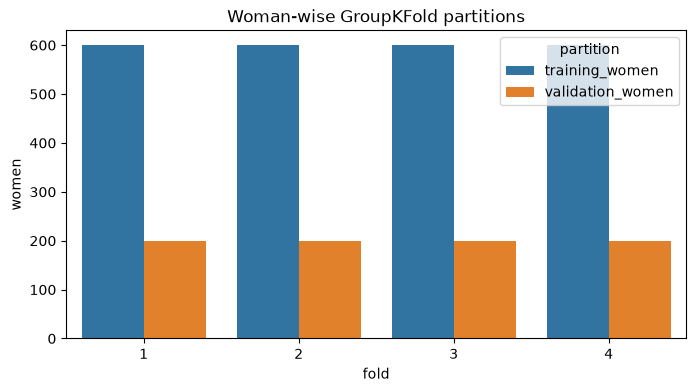

In [2]:
cv = GroupKFold(n_splits=4)
fold_rows = []
for fold, (train_idx, validation_idx) in enumerate(cv.split(X, y, groups), start=1):
    train_groups = set(groups.iloc[train_idx])
    validation_groups = set(groups.iloc[validation_idx])
    assert not (train_groups & validation_groups)
    fold_rows.append(
        {
            "fold": fold,
            "training_rows": len(train_idx),
            "validation_rows": len(validation_idx),
            "training_women": len(train_groups),
            "validation_women": len(validation_groups),
            "woman_overlap": len(train_groups & validation_groups),
        }
    )
fold_summary = pd.DataFrame(fold_rows)
display(fold_summary)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=fold_summary.melt(
        id_vars="fold",
        value_vars=["training_women", "validation_women"],
        var_name="partition",
        value_name="women",
    ),
    x="fold",
    y="women",
    hue="partition",
)
plt.title("Woman-wise GroupKFold partitions")
plt.show()

## 4. Define the search space and metric

Notebook 05 uses `RandomizedSearchCV` with seed 42 to evaluate a bounded sample of up to 12 configurations for each candidate model. Each sampled configuration is evaluated over all four woman-wise folds. `neg_mean_absolute_error` is scikit-learn's maximization form of MAE; the reported value is converted back to positive MAE, where lower is better.

In [3]:
parameter_space = {
    "model__n_estimators": [150, 250, 350],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 1.0],
}
space_table = pd.DataFrame(
    {
        "hyperparameter": parameter_space.keys(),
        "candidate_values": [str(v) for v in parameter_space.values()],
    }
)
display(space_table)
print(
    "Fixed values: objective=reg:squarederror; random_state=42; n_jobs=-1"
)
print("Optimisation objective: minimize cross-validated MAE.")

,hyperparameter,candidate_values
0,model__n_estimators,"[150, 250, 350]"
1,model__learning_rate,"[0.03, 0.05, 0.1]"
2,model__max_depth,"[2, 3, 4]"
3,model__subsample,"[0.7, 0.9, 1.0]"
4,model__colsample_bytree,"[0.7, 1.0]"


Fixed values: objective=reg:squarederror; random_state=42; n_jobs=-1
Optimisation objective: minimize cross-validated MAE.


## 5. Load the authoritative tuning decision

The imputer is inside the Pipeline, so it is fitted separately inside every CV training fold. This avoids calculating median values from a fold's validation women.

In [4]:
# Notebook 05 is the sole authoritative tuning run; this notebook only presents its audit trail.
with open(ROOT / "results" / "tuning" / "best_tuned_model.json") as f: authoritative_selection = json.load(f)
assert authoritative_selection["model"] == "XGBRegressor", "Notebook 05 must be rerun before this XGBoost audit."
print("Selected Model:", authoritative_selection["model"])
print("Best Hyperparameters:", authoritative_selection["best_params"])
print("Grouped CV MAE:", authoritative_selection["best_cv_mae"])

Selected Model: XGBRegressor
Best Hyperparameters: {'model__subsample': 0.9, 'model__n_estimators': 250, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Grouped CV MAE: 1.2332301753759385


## 6. Inspect every sampled configuration

This table records the best grouped-CV result reached for each tuned model family. Notebook 05 is the source of truth for the detailed searches; this notebook intentionally does not run a second search.

In [5]:
trials = pd.read_csv(ROOT / "results" / "tuning" / "tuning_leaderboard.csv").sort_values("best_cv_mae").reset_index(drop=True)
display(trials)
print("This audit displays the one authoritative GroupKFold tuning process from Notebook 05.")

,model,best_cv_mae,runtime_seconds,best_params
0,XGBRegressor,1.233230,4.499658,"{'model__subsample': 0.9, 'model__n_estimators..."
1,GradientBoostingRegressor,1.237281,35.784607,"{'model__n_estimators': 100, 'model__min_sampl..."
2,HistGradientBoostingRegressor,1.237591,8.755294,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
3,RandomForestRegressor,1.240400,65.077320,"{'model__n_estimators': 350, 'model__min_sampl..."
4,SVR,1.268274,82.634218,"{'model__gamma': 0.03, 'model__epsilon': 0.25,..."


This audit displays the one authoritative GroupKFold tuning process from Notebook 05.


## 7. Visualise the optimisation outcome

The first chart compares every random-search trial. The second chart shows how mean CV MAE changes across key hyperparameter values. These are visual diagnostics, not a claim that one parameter is independently causal, because each trial changes multiple settings.

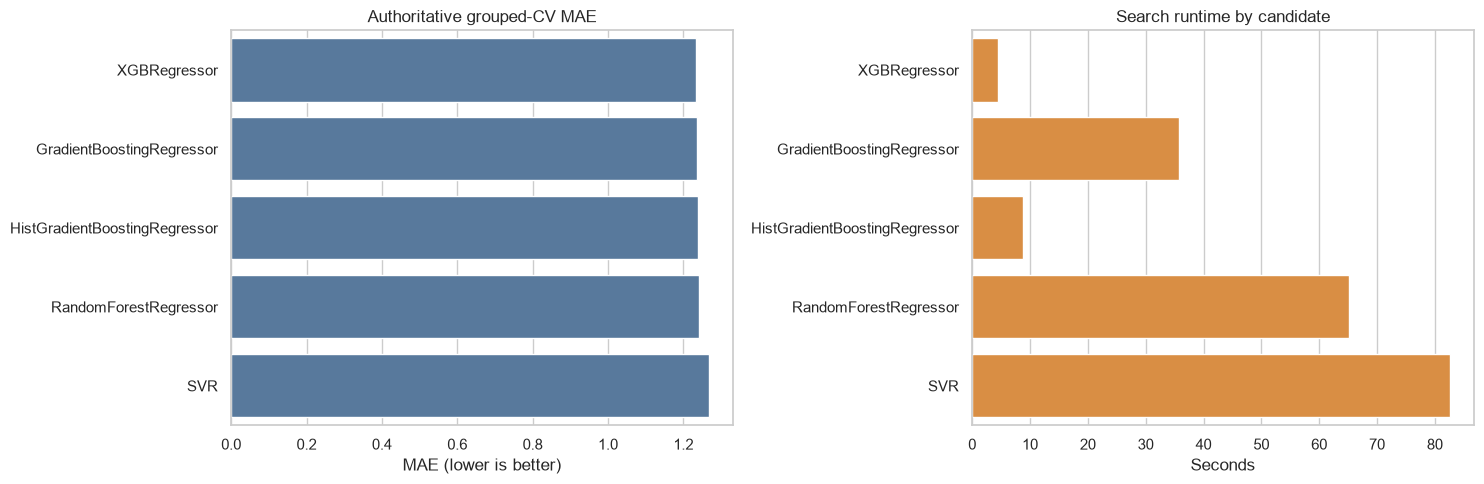

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=trials, y="model", x="best_cv_mae", ax=axes[0], color="#4C78A8")
axes[0].set(title="Authoritative grouped-CV MAE", xlabel="MAE (lower is better)", ylabel="")
sns.barplot(data=trials, y="model", x="runtime_seconds", ax=axes[1], color="#F28E2B")
axes[1].set(title="Search runtime by candidate", xlabel="Seconds", ylabel="")
plt.tight_layout(); plt.show()
fig.savefig(ROOT / "results" / "plots" / "hyperparameter_optimisation_audit.png", dpi=180, bbox_inches="tight")

## 8. Save the selected configuration and audit trail

The final test set remains unused. This notebook is a panel-facing audit of the selected XGBRegressor configuration; Notebook 09 performs the final held-out evaluation using the locked selection recorded by Notebook 05.

In [7]:
tuning_dir = ROOT / "results" / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)
audit = {"selected_estimator": authoritative_selection["model"], "search_method": "Notebook 05: RandomizedSearchCV with GroupKFold(n_splits=4)", "optimisation_metric": "mean grouped CV MAE", "best_cv_mae": authoritative_selection["best_cv_mae"], "best_parameters": authoritative_selection["best_params"]}
with open(tuning_dir / "hyperparameter_optimisation_audit.json", "w") as f: json.dump(audit, f, indent=2)
display(pd.DataFrame([audit]).drop(columns=["best_parameters"]))
print("Saved an audit of the authoritative tuning result; no second search was run.")

,selected_estimator,search_method,optimisation_metric,best_cv_mae
0,XGBRegressor,Notebook 05: RandomizedSearchCV with GroupKFol...,mean grouped CV MAE,1.23323


Saved an audit of the authoritative tuning result; no second search was run.


## Panel-ready summary

Notebook 05 used **RandomizedSearchCV** to evaluate a bounded, reproducible sample of up to 12 configurations for each candidate model. Each configuration used **four woman-wise GroupKFold folds**, and **XGBRegressor** had the lowest mean validation MAE in the saved leaderboard. The final test women were not used during this decision, so the final test score remains an unbiased estimate.